In [1]:
import cv2


Matrix J shape: (10752, 100)


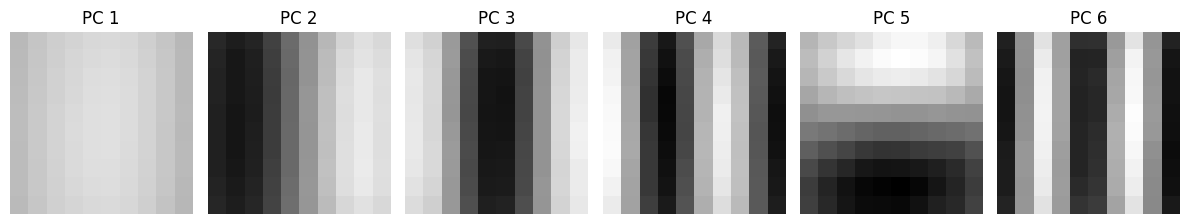

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def analyze_image_pca(file_path):
    # 1. Load the data
    # The file contains a matrix of pixel values
    try:
        img = np.loadtxt(file_path)
    except FileNotFoundError:
        print("File not found. Please ensure 'Trees.txt' is in the working directory.")
        return

    # Get image dimensions
    height, width = img.shape
    patch_size = 10
    
    # 2. Transform the image to a set of non-overlapping 10x10 patches
    # 3. Flatten the patches into 100-dimensional vectors
    patches = []
    
    # Iterate over the image with a step size of 10 to ensure non-overlapping
    for i in range(0, height, patch_size):
        for j in range(0, width, patch_size):
            # Extract the patch
            patch = img[i:i+patch_size, j:j+patch_size]
            
            # Ensure we only take full 10x10 patches (in case image size isn't divisible by 10)
            if patch.shape == (patch_size, patch_size):
                # Flatten patch into a vector and append to list
                patches.append(patch.flatten())

    # 4. Stack the vectors into a matrix J
    # shape will be (n_patches, 100)
    J = np.array(patches)
    print(f"Matrix J shape: {J.shape}")

    # 5. Calculate the first 6 principal components
    n_components = 6
    pca = PCA(n_components=n_components)
    pca.fit(J)
    
    # The components_ attribute contains the eigenvectors (principal components)
    # Shape is (n_components, n_features) -> (6, 100)
    components = pca.components_

    # 6. Show them as image patches
    fig, axes = plt.subplots(1, 6, figsize=(12, 3))
    
    # Determine global min and max to ensure the same grey scale for all plots
    vmin = components.min()
    vmax = components.max()

    for i, ax in enumerate(axes):
        # Reshape the 100-dim vector back into a 10x10 image patch
        pc_image = components[i].reshape(patch_size, patch_size)
        
        # Display using the same colormap limits (vmin, vmax)
        ax.imshow(pc_image, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(f'PC {i+1}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Run the function
analyze_image_pca('Trees.txt')